In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("✅ Imports successful")

✅ Imports successful


In [3]:
# Loading all 4 datasets
train = pd.read_csv('data/raw/train.csv')
stores = pd.read_csv('data/raw/stores.csv')
features = pd.read_csv('data/raw/features.csv')
test = pd.read_csv('data/raw/test.csv')

# Quick check
print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Features shape:", features.shape)
print("Test shape:", test.shape)

Train shape: (421570, 5)
Stores shape: (45, 3)
Features shape: (8190, 12)
Test shape: (115064, 4)


In [4]:
print("=== TRAIN ===")
print(train.head())
print("\n=== STORES ===")
print(stores.head())
print("\n=== FEATURES ===")
print(features.head())

=== TRAIN ===
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False

=== STORES ===
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875

=== FEATURES ===
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0      

In [5]:
print("=== MISSING VALUES ===")
print("\nTrain:")
print(train.isnull().sum())
print("\nFeatures:")
print(features.isnull().sum())
print("\nStores:")
print(stores.isnull().sum())

=== MISSING VALUES ===

Train:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Stores:
Store    0
Type     0
Size     0
dtype: int64


In [7]:
# Merge train with stores
df = train.merge(stores, on='Store', how='left')

# Merge with features
df = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# Fill CPI and Unemployment with forward fill
df['CPI'] = df['CPI'].fillna(method='ffill')
df['Unemployment'] = df['Unemployment'].fillna(method='ffill')

print("Merged dataframe shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values after merge:")
print(df.isnull().sum())

Merged dataframe shape: (421570, 16)

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']

Missing values after merge:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64


In [9]:
print("=== DATASET OVERVIEW ===")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of stores: {df['Store'].nunique()}")
print(f"Number of departments: {df['Dept'].nunique()}")
print(f"Store types: {df['Type'].unique()}")
print(f"\nWeekly Sales Stats:")
print(df['Weekly_Sales'].describe())

=== DATASET OVERVIEW ===
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Number of stores: 45
Number of departments: 81
Store types: ['A' 'B' 'C']

Weekly Sales Stats:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


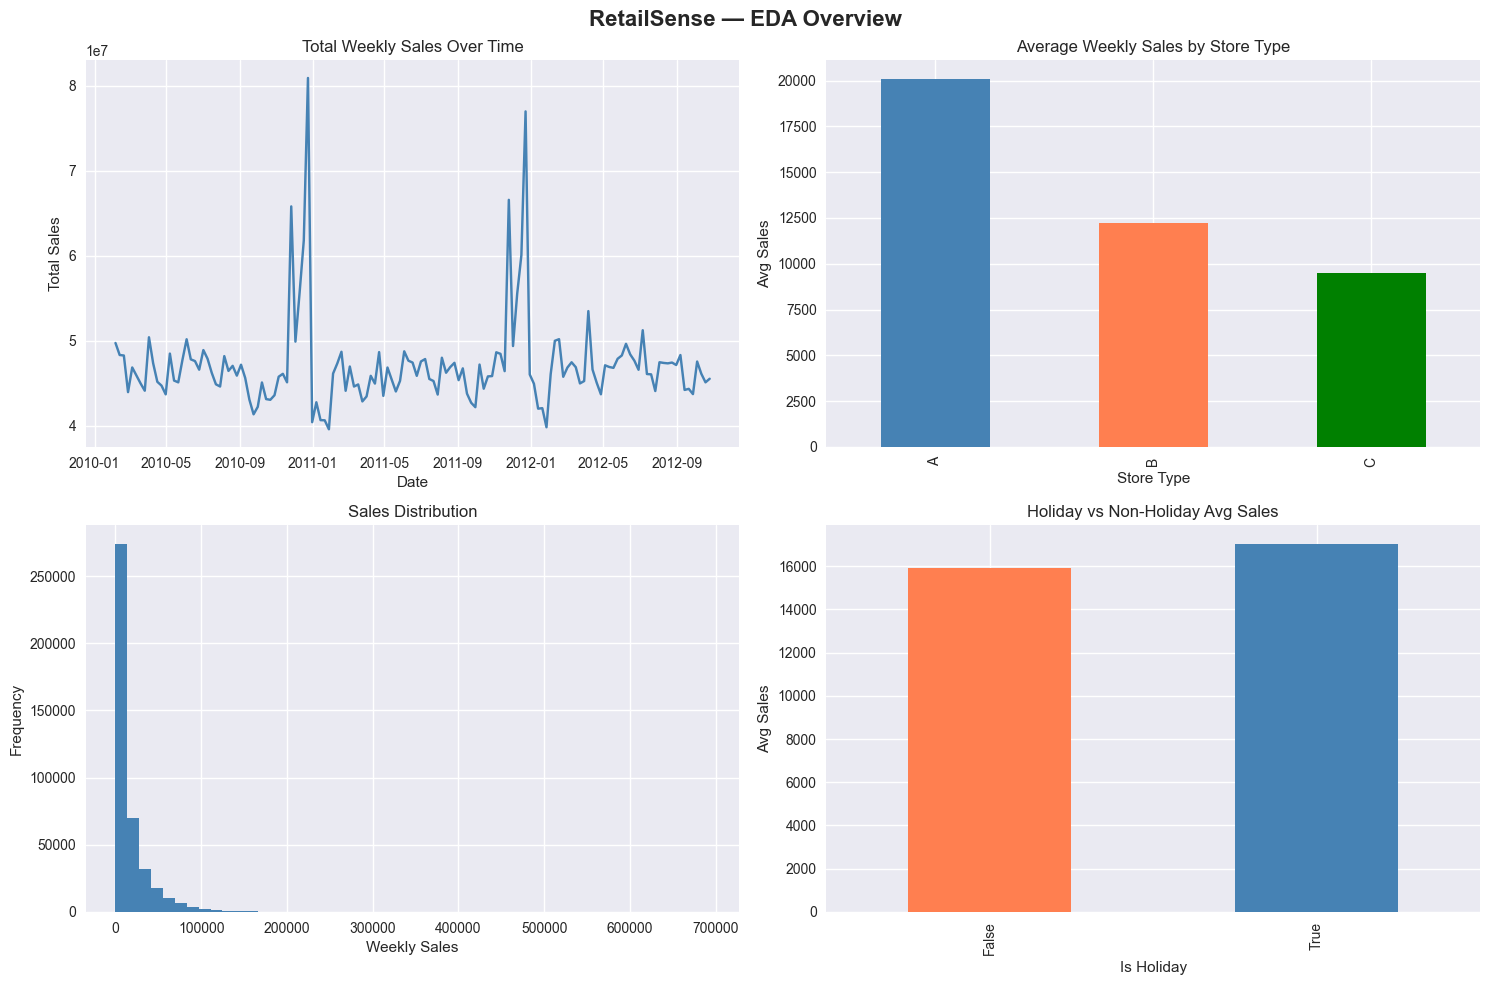

✅ Plot saved to docs/


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('RetailSense — EDA Overview', fontsize=16, fontweight='bold')

# 1. Total weekly sales over time
weekly = df.groupby('Date')['Weekly_Sales'].sum()
axes[0,0].plot(weekly.index, weekly.values, color='steelblue')
axes[0,0].set_title('Total Weekly Sales Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Total Sales')

# 2. Sales by store type
df.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0,1], color=['steelblue','coral','green'])
axes[0,1].set_title('Average Weekly Sales by Store Type')
axes[0,1].set_xlabel('Store Type')
axes[0,1].set_ylabel('Avg Sales')

# 3. Sales distribution (remove negatives for viz)
df[df['Weekly_Sales'] > 0]['Weekly_Sales'].plot(kind='hist', bins=50, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Sales Distribution')
axes[1,0].set_xlabel('Weekly Sales')

# 4. Holiday vs Non-Holiday sales
df.groupby('IsHoliday')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[1,1], color=['coral','steelblue'])
axes[1,1].set_title('Holiday vs Non-Holiday Avg Sales')
axes[1,1].set_xlabel('Is Holiday')
axes[1,1].set_ylabel('Avg Sales')

plt.tight_layout()
plt.savefig('docs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to docs/")

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save clean merged dataframe
df.to_csv('../data/processed/merged_clean.csv', index=False)

print("✅ Processed data saved!")
print(f"Shape: {df.shape}")
print(f"Saved to: data/processed/merged_clean.csv")

✅ Processed data saved!
Shape: (421570, 16)
Saved to: data/processed/merged_clean.csv


FileNotFoundError: [Errno 2] No such file or directory: '../docs/seasonality.png'

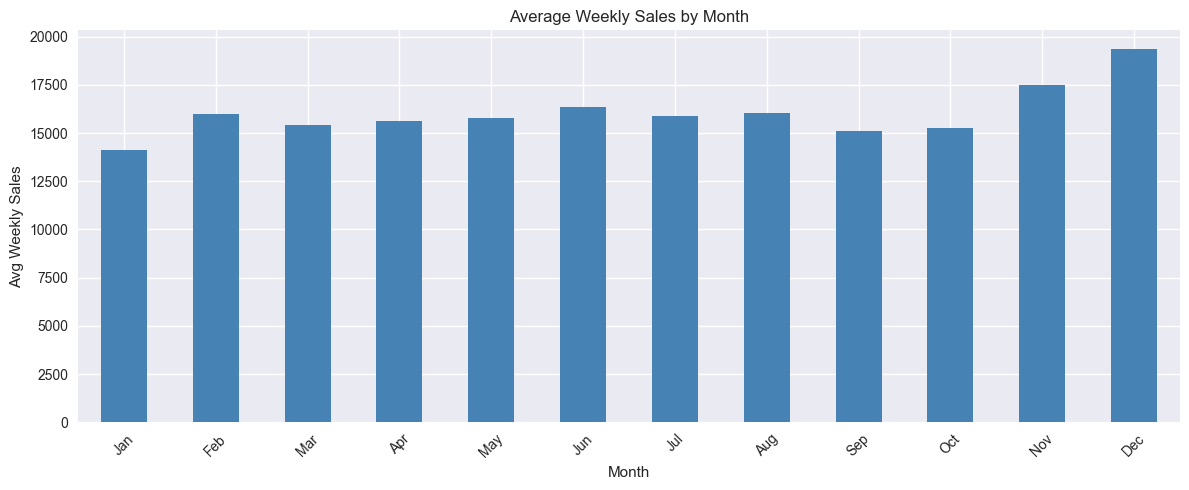

In [13]:
# Extract month and week
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Year'] = df['Date'].dt.year

# Monthly average sales
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='bar', color='steelblue')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales')
plt.xticks(ticks=range(12), 
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], 
           rotation=45)
plt.tight_layout()
plt.savefig('../docs/seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Seasonality plot saved!")

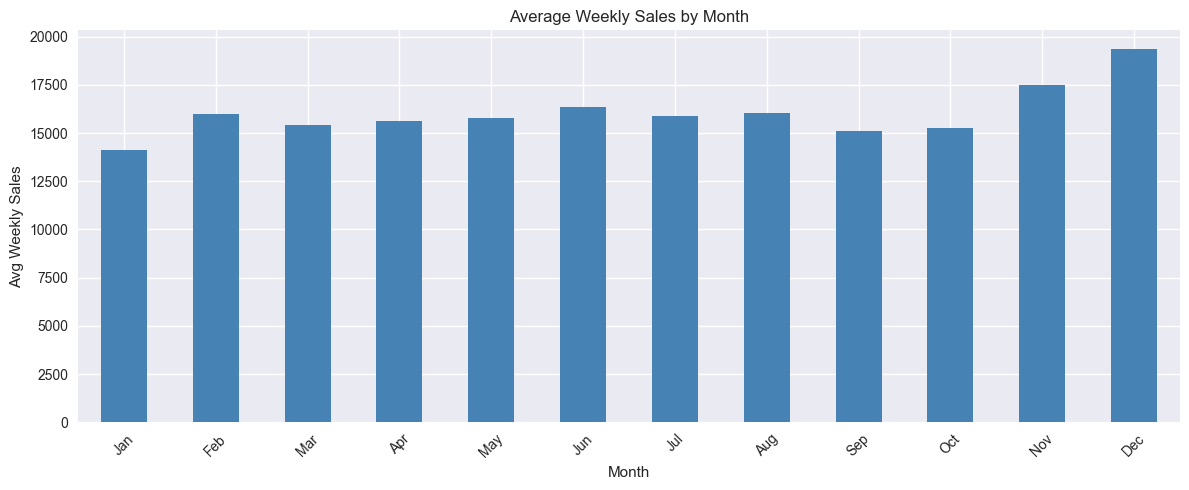

✅ Saved!


In [14]:
import os
os.makedirs('../docs', exist_ok=True)

# Resave both plots
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='bar', color='steelblue')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales')
plt.xticks(ticks=range(12), 
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], 
           rotation=45)
plt.tight_layout()
plt.savefig('../docs/seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")